# Task-2 Flowchart Games - Decision Trees

To grasp the intuitive decision-making process of Decision Trees, likened to a “20 Questions” game. Learners will understand how trees recursively split data based on features to arrive at a prediction, and how to interpret their structure.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report 
import seaborn as sns

In [3]:
# Generate synthetic data for Decision Tree
np.random.seed(42)

# Class 0: Not Buy
X_dt0 = np.random.normal(loc=[30, 40000], scale=[8, 10000], size=(60, 2))
y_dt0 = np.zeros(60)

# Class 1: Buy
X_dt1 = np.random.normal(loc=[50, 70000], scale=[10, 15000], size=(60, 2))
y_dt1 = np.ones(60)

# Combine data
X_dt = np.vstack((X_dt0, X_dt1))
y_dt = np.hstack((y_dt0, y_dt1))

df_dt = pd.DataFrame(X_dt, columns=['Age', 'Income'])
df_dt['Decision'] = y_dt

display(df_dt.head())

,Age,Income,Decision
0,33.973713,38617.356988,0.0
1,35.181508,55230.298564,0.0
2,28.126773,37658.630431,0.0
3,42.633703,47674.347292,0.0
4,26.244205,45425.600436,0.0


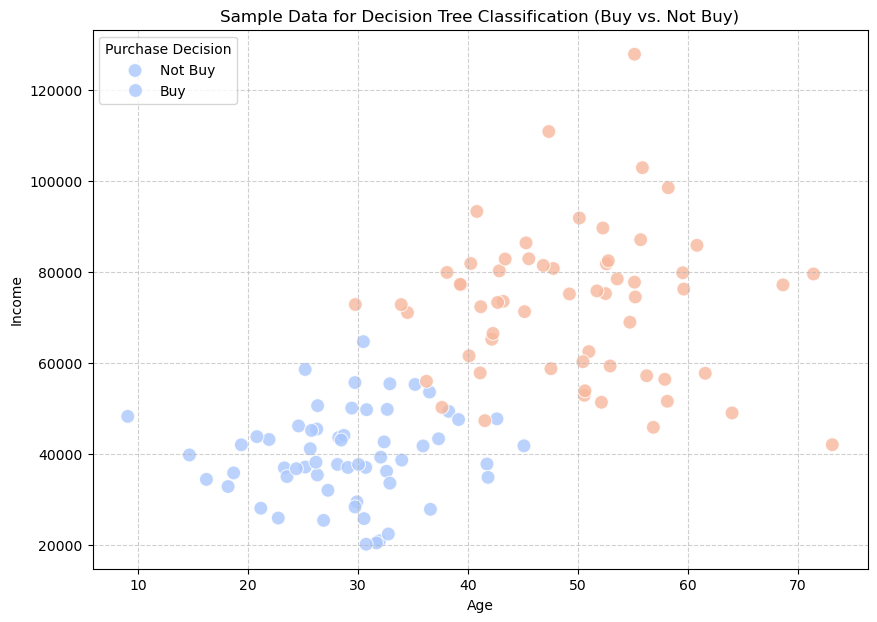

In [4]:
# Plot the generated data for Decision Tree
plt.figure(figsize=(10, 7))

sns.scatterplot(
    x='Age',
    y='Income',
    hue='Decision',
    data=df_dt,
    palette='coolwarm',
    s=100,
    alpha=0.8
)

plt.title('Sample Data for Decision Tree Classification (Buy vs. Not Buy)')
plt.xlabel('Age')
plt.ylabel('Income')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Purchase Decision', loc='upper left', labels=['Not Buy', 'Buy'])
plt.show()

In [5]:
# Split data for Decision Tree
X_dt_train, X_dt_test, y_dt_train, y_dt_test = train_test_split(
    X_dt, y_dt, test_size=0.3, random_state=42
)

print(f"Training set shape for DT: {X_dt_train.shape}, {y_dt_train.shape}")
print(f"Testing set shape for DT: {X_dt_test.shape}, {y_dt_test.shape}")

Training set shape for DT: (84, 2), (84,)
Testing set shape for DT: (36, 2), (36,)


In [6]:
# Initialize Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(max_depth=3, random_state=42)

# Train the model
dt_classifier.fit(X_dt_train, y_dt_train)

print("Decision Tree Classifier trained successfully.")

Decision Tree Classifier trained successfully.


In [7]:
# Make predictions on the test data
y_dt_pred = dt_classifier.predict(X_dt_test)

print("First 10 actual labels for DT:", y_dt_test[:10])
print("First 10 predicted labels for DT:", y_dt_pred[:10])

First 10 actual labels for DT: [0. 0. 0. 0. 0. 1. 1. 0. 0. 1.]
First 10 predicted labels for DT: [0. 0. 0. 0. 0. 1. 0. 0. 0. 1.]


In [8]:
# Evaluate the Decision Tree model's performance
dt_accuracy = accuracy_score(y_dt_test, y_dt_pred)
dt_report = classification_report(y_dt_test, y_dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)
print("Decision Tree Classification Report:\n", dt_report)

Decision Tree Accuracy: 0.9166666666666666
Decision Tree Classification Report:
               precision    recall  f1-score   support

         0.0       0.94      0.89      0.92        19
         1.0       0.89      0.94      0.91        17

    accuracy                           0.92        36
   macro avg       0.92      0.92      0.92        36
weighted avg       0.92      0.92      0.92        36



## Visualization

I used a scatter plot to visualize the relationship between Age and Income for the Buy and Not Buy classes. I also used "plot_tree()" to display the structure and decision-making process of the trained Decision Tree.

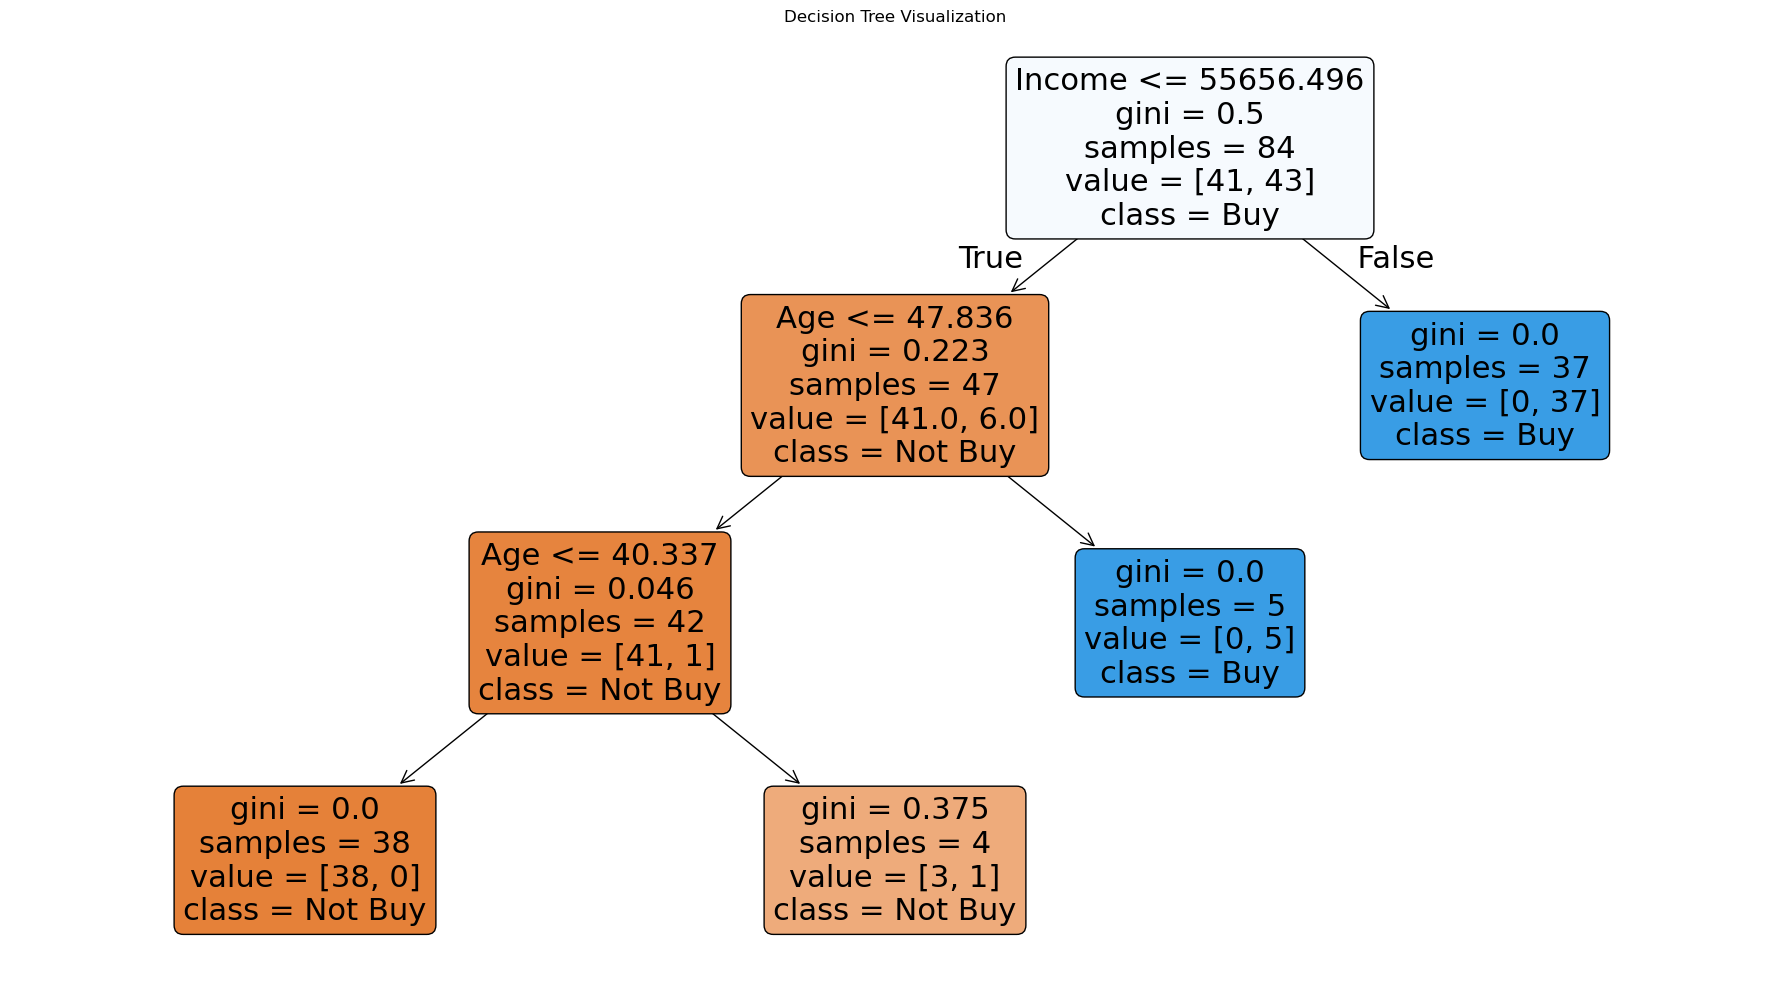

In [16]:
plt.figure(figsize=(18, 10))

plot_tree(
    dt_classifier,
    feature_names=['Age', 'Income'],
    class_names=['Not Buy', 'Buy'],
    filled=True,
    rounded=True
)

plt.title('Decision Tree Visualization')
plt.tight_layout()
plt.show()

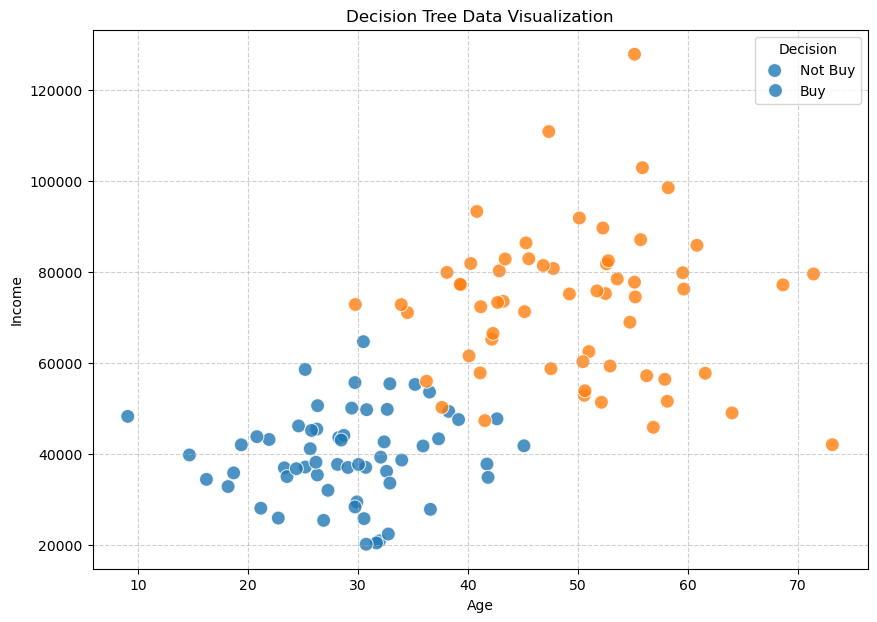

In [13]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    x='Age',
    y='Income',
    hue='Decision',
    data=df_dt,
    s=100,
    alpha=0.8
)

plt.title('Decision Tree Data Visualization')
plt.xlabel('Age')
plt.ylabel('Income')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Decision', labels=['Not Buy', 'Buy'])
plt.show()